平均の誤差を流用

Using p range: [0.720000, 0.900000]  (N=37)


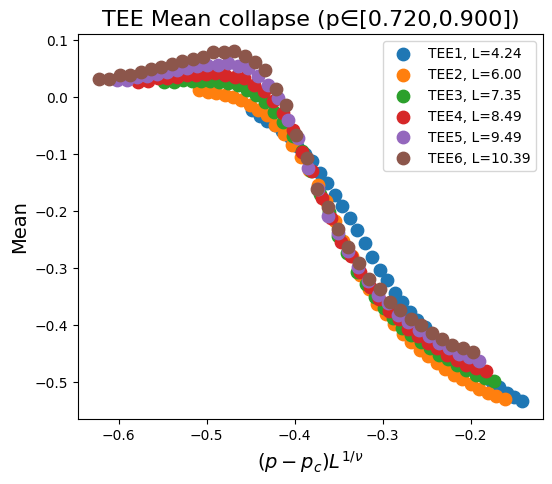

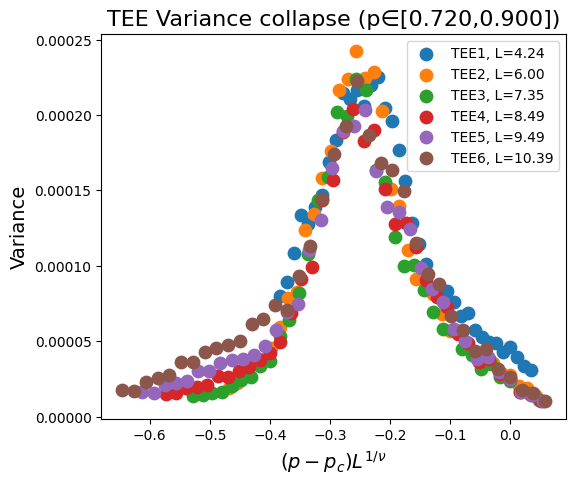

=== 平均 FSS ===
pc = 0.9835959495153603 ± 0.005358364784250689
nu = 2.725470207691261 ± nan
zeta = 0.8490749078608117 ± 0.45518999272813965
S (mean) = 1340.1946585985725

=== 分散 FSS ===
pc = 0.8851265006932361 ± 0.051039524649819236
nu = 1.7172665435577739 ± 1.1008870444828438
zeta = 3.3724316177673996 ± 1.5142394834337416
S (var)  = 0.23825306815399247

=== 生の誤差配列（マスク後） ===
da_mean_sel shape: (6, 37) (nL, nP)
da_var_sel  shape: (6, 37) (nL, nP)
[TEE1] da_mean_sel[0, :]: [0.00082654 0.00087519 0.00096216 0.00106944 0.00104574 0.0010918  0.001122   0.00120146 0.0012531  0.00135493 0.00134274 0.00136096 0.00132728 0.00137263
 0.0013875  0.00132349 0.001296   0.00123027 0.00115682 0.00104705 0.00098875 0.00093109 0.00084939 0.00085164 0.00084286 0.00080744 0.00075644 0.00076573
 0.00070235 0.000672   0.00065213 0.00064528 0.00060512 0.00062688 0.0005806  0.00053466 0.00051365]
[TEE2] da_mean_sel[1, :]: [0.00056197 0.00061703 0.00067785 0.00077242 0.00080607 0.000874   0.00100167 0.00115251

In [2]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.72, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                          rho_c0=0.86, nu0=1.82, zeta0=2.9)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

# ======================
# 誤差の標準出力（そのまま / 要約）
# ======================
np.set_printoptions(linewidth=160, suppress=True)

print("\n=== 生の誤差配列（マスク後） ===")
print("da_mean_sel shape:", da_mean_sel.shape, "(nL, nP)")
print("da_var_sel  shape:", da_var_sel.shape,  "(nL, nP)")

# Lごとに1行で出力（大きいなら要約だけ使ってください）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel[{i}, :]:", da_mean_sel[i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel [{i}, :]:", da_var_sel[i])

# スケーリング後の y-誤差（collapse座標の誤差）
print("\n=== collapse後の誤差（dys_*） ===")
print("dys_mean shape:", dys_mean.shape, "(nP, nL)")
print("dys_var  shape:", dys_var.shape,  "(nP, nL)")

# 行列を Lごとに1列として出したい場合（必要なら）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean[:, {i}]:", dys_mean[:, i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var [:, {i}]:", dys_var[:, i])

# 見やすい要約統計（最小値/中央値/最大値）
def stats(a):
    return dict(min=float(np.nanmin(a)), median=float(np.nanmedian(a)), max=float(np.nanmax(a)))

print("\n=== 誤差の要約統計 ===")
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel stats:", stats(da_mean_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel  stats:", stats(da_var_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean     stats:", stats(dys_mean[:, i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var      stats:", stats(dys_var[:, i]))

# どれだけ残っているかを可視化
print("len(pg) =", len(p_all))
print("count in [pmin,pmax] =", np.count_nonzero((p_all >= pmin) & (p_all <= pmax)))
print("pg in window (head):", p_all[(p_all >= pmin) & (p_all <= pmax)][:10])

# Lごとに NaN/inf がないか（窓内のみで）
mask = (p_all >= pmin) & (p_all <= pmax)
for i, key in enumerate(TEE_keys):
    ok = np.isfinite(a_var[i, mask]) & np.isfinite(da_var[i, mask])
    print(f"{key}: window points =", np.sum(mask),
          " usable =", np.count_nonzero(ok),
          " dropped =", np.sum(~ok))

Using p range: [0.830000, 0.900000]  (N=8)


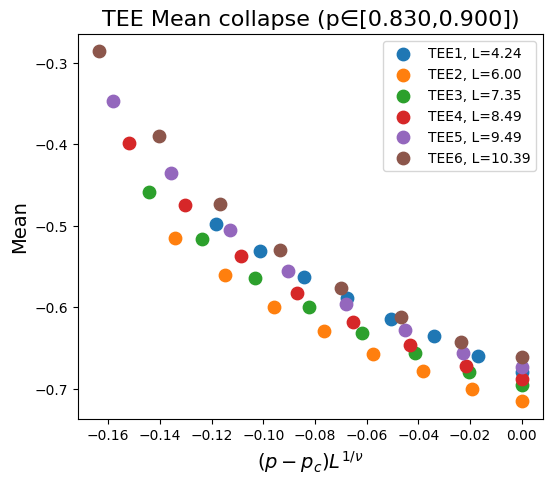

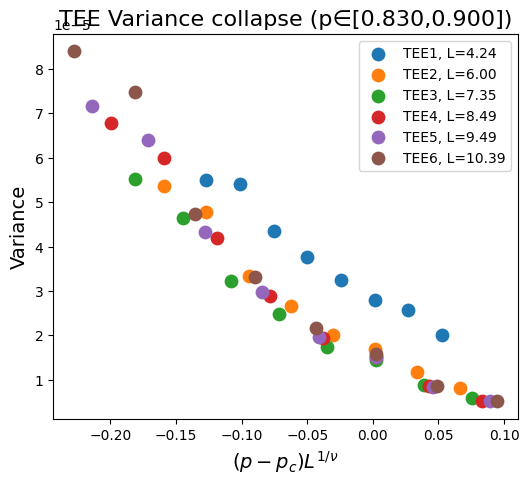

=== 平均 FSS ===
pc = 0.8999996433690687 ± 0.07558008279748692
nu = 2.7593941178983554 ± 1.1233391616150978
zeta = 0.39886804577434487 ± 0.324889172150387
S (mean) = 1338.9731125953583

=== 分散 FSS ===
pc = 0.8794420199681863 ± nan
nu = 1.533482487625803 ± 0.4444805885305066
zeta = 3.4657505171908323 ± nan
S (var)  = 0.09707053788504484

=== 生の誤差配列（マスク後） ===
da_mean_sel shape: (6, 8) (nL, nP)
da_var_sel  shape: (6, 8) (nL, nP)
[TEE1] da_mean_sel[0, :]: [0.00084939 0.00084286 0.00075644 0.00070235 0.00065213 0.00060512 0.0005806  0.00051365]
[TEE2] da_mean_sel[1, :]: [0.00124048 0.00117235 0.00098004 0.00087674 0.00076101 0.00069737 0.00058146 0.00048443]
[TEE3] da_mean_sel[2, :]: [0.00158495 0.00145312 0.00121069 0.00106374 0.00089167 0.00081402 0.00063782 0.00052346]
[TEE4] da_mean_sel[3, :]: [0.00206614 0.00194004 0.00162573 0.00134798 0.00110329 0.00097512 0.00073748 0.00058028]
[TEE5] da_mean_sel[4, :]: [0.00240622 0.00227628 0.00187379 0.00155312 0.00126373 0.00111141 0.00082331 0.00

In [4]:
import numpy as np
import fssa
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ======================
# 設定
# ======================
gamma = 0.5

# L と TEE キー
# L_list は FSSA のスケール長 (L) を入れる。ここでは sqrt(セル数) を使用。
L_list = [np.sqrt(18),np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_keys = ['TEE1','TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']

#L_list = [np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
#TEE_keys = ['TEE3', 'TEE4', 'TEE5', 'TEE6']

# データファイル
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# カラーマップ
cmap = cm.get_cmap('gnuplot', 4)

# ======================
# p の使用範囲の指定（いずれか1つを有効に）
# ======================
# 方式A: 値で指定（例: 0.30 <= p <= 0.90）
use_by_value = True
pmin, pmax = 0.83, 0.9

# 方式B: 連続インデックスで指定（例: 5〜45 まで）
idx_slice = None  # 例: slice(5, 46)

# 方式C: 個別インデックスのリスト（例: 偶数番だけ）
idx_list = None   # 例: [0, 2, 4, 6, 8]

# ======================
# データ読み込み
# ======================
data = np.load(npz_path)
p_all = data['pg']  # 全 p
# a_mean, da_mean, a_var, da_var を先に作り、あとで列方向に同じマスクを適用
a_mean = np.array([data[f'{k}_ave'] for k in TEE_keys], dtype=float)       # shape=(nL, nP)
da_mean = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma
a_var  = np.array([data[f'{k}_var'] for k in TEE_keys], dtype=float)
da_var = np.array([data[f'{k}_err'] for k in TEE_keys], dtype=float) * gamma  # 仮に同じ誤差を使用

# ======================
# マスク作成
# ======================
if use_by_value:
    mask = (p_all >= pmin) & (p_all <= pmax)
elif idx_slice is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[idx_slice] = True
elif idx_list is not None:
    mask = np.zeros_like(p_all, dtype=bool)
    mask[np.array(idx_list, dtype=int)] = True
else:
    mask = np.ones_like(p_all, dtype=bool)  # 全部使う

# 安全チェック
if not np.any(mask):
    raise ValueError("選択マスクが空です。p の範囲やインデックス指定を見直してください。")

# マスク適用（列方向＝p軸に沿って揃える）
p_use = p_all[mask]
a_mean_sel  = a_mean[:,  mask]
da_mean_sel = da_mean[:, mask]
a_var_sel   = a_var[:,   mask]
da_var_sel  = da_var[:,  mask]

print(f"Using p range: [{p_use.min():.6f}, {p_use.max():.6f}]  (N={p_use.size})")

# ======================
# 平均値 FSS
# ======================
ret_mean = fssa.autoscale(L_list, p_use, a_mean_sel, da_mean_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_mean, ys_mean, dys_mean = fssa.scaledata(L_list, p_use, a_mean_sel, da_mean_sel,
                                            ret_mean.rho, ret_mean.nu, ret_mean.zeta)

# ----------------------
# 平均のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_mean.T[:, i], ys_mean.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Mean', fontsize=14)
ax.legend()
plt.title(f"TEE Mean collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_mean.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 分散 FSS
# ======================
ret_var = fssa.autoscale(L_list, p_use, a_var_sel, da_var_sel,
                         rho_c0=0.87, nu0=1.73, zeta0=3.3)
xs_var, ys_var, dys_var = fssa.scaledata(L_list, p_use, a_var_sel, da_var_sel,
                                         ret_var.rho, ret_var.nu, ret_var.zeta)

# ----------------------
# 分散のプロット
# ----------------------
fig, ax = plt.subplots(figsize=(6,5))
for i, (L, key) in enumerate(zip(L_list, TEE_keys)):
    ax.scatter(xs_var.T[:, i], ys_var.T[:, i],
               label=f'{key}, L={L:.2f}', s=80)
ax.set_xlabel(r'$(p-p_c)L^{1/\nu}$', fontsize=14)
ax.set_ylabel('Variance', fontsize=14)
ax.legend()
plt.title(f"TEE Variance collapse (p∈[{p_use.min():.3f},{p_use.max():.3f}])", fontsize=16)

plt.savefig("TEE_variance.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# ======================
# 結果表示
# ======================
print("=== 平均 FSS ===")
print("pc =", ret_mean.rho, "±", ret_mean.drho)
print("nu =", ret_mean.nu,  "±", ret_mean.dnu)
print("zeta =", ret_mean.zeta, "±", ret_mean.dzeta)
print("S (mean) =", fssa.quality(xs_mean, ys_mean, dys_mean))

print("\n=== 分散 FSS ===")
print("pc =", ret_var.rho, "±", ret_var.drho)
print("nu =", ret_var.nu,  "±", ret_var.dnu)
print("zeta =", ret_var.zeta, "±", ret_var.dzeta)
print("S (var)  =", fssa.quality(xs_var, ys_var, dys_var))

# ======================
# 誤差の標準出力（そのまま / 要約）
# ======================
np.set_printoptions(linewidth=160, suppress=True)

print("\n=== 生の誤差配列（マスク後） ===")
print("da_mean_sel shape:", da_mean_sel.shape, "(nL, nP)")
print("da_var_sel  shape:", da_var_sel.shape,  "(nL, nP)")

# Lごとに1行で出力（大きいなら要約だけ使ってください）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel[{i}, :]:", da_mean_sel[i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel [{i}, :]:", da_var_sel[i])

# スケーリング後の y-誤差（collapse座標の誤差）
print("\n=== collapse後の誤差（dys_*） ===")
print("dys_mean shape:", dys_mean.shape, "(nP, nL)")
print("dys_var  shape:", dys_var.shape,  "(nP, nL)")

# 行列を Lごとに1列として出したい場合（必要なら）
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean[:, {i}]:", dys_mean[:, i])
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var [:, {i}]:", dys_var[:, i])

# 見やすい要約統計（最小値/中央値/最大値）
def stats(a):
    return dict(min=float(np.nanmin(a)), median=float(np.nanmedian(a)), max=float(np.nanmax(a)))

print("\n=== 誤差の要約統計 ===")
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_mean_sel stats:", stats(da_mean_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] da_var_sel  stats:", stats(da_var_sel[i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_mean     stats:", stats(dys_mean[:, i]))
for i, key in enumerate(TEE_keys):
    print(f"[{key}] dys_var      stats:", stats(dys_var[:, i]))

# どれだけ残っているかを可視化
print("len(pg) =", len(p_all))
print("count in [pmin,pmax] =", np.count_nonzero((p_all >= pmin) & (p_all <= pmax)))
print("pg in window (head):", p_all[(p_all >= pmin) & (p_all <= pmax)][:10])

# Lごとに NaN/inf がないか（窓内のみで）
mask = (p_all >= pmin) & (p_all <= pmax)
for i, key in enumerate(TEE_keys):
    ok = np.isfinite(a_var[i, mask]) & np.isfinite(da_var[i, mask])
    print(f"{key}: window points =", np.sum(mask),
          " usable =", np.count_nonzero(ok),
          " dropped =", np.sum(~ok))

Best over grid (nu fixed=1.3333): pc≈0.870000, zeta≈2.8417, S≈0.2423


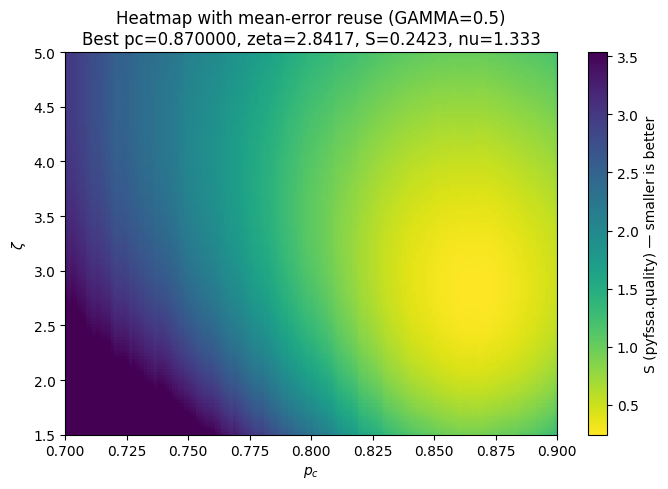

In [34]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [1, 2, 3, 4, 5, 6]    # TEE1..TEE6 を使用

# p窓
pc_min, pc_max = 0.72, 0.9

# ---- 固定 ν ----
NU_FIXED = 4/3

# 探索レンジ
PC_RANGE   = (0.7, 0.9)
ZETA_RANGE = (1.5,  5.0)
N_PC, N_ZETA = 161, 121

# 誤差スケール（平均err流用時の任意係数）
GAMMA = 0.5   # (=1で素の流用。0.5にすると重み×4になるので注意)

# 誤差フロア（ゼロ重み/過小見積りの暴走回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と "平均の誤差を流用"）
# ======================
dat = np.load(npz_path)
pg = dat["pg"].astype(float)

def key(c): return f"TEE{c}"
a_var   = np.array([dat[f"{key(c)}_var"] for c in TEE_cols], float)       # shape=(nL,nP)
# ここがポイント：分散の誤差に「平均の誤差」を流用
da_mean = np.array([dat[f"{key(c)}_err"] for c in TEE_cols], float) * GAMMA
da_var  = da_mean.copy()

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
if not np.any(mask):
    raise ValueError("p窓にデータがありません。pc_min/max を見直してください。")

pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並べる ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (p_c, ζ) グリッドで S=quality を評価（νは固定）
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)

S_grid = np.full((N_ZETA, N_PC), np.nan, dtype=float)
bestS, best_pc, best_zeta = np.inf, None, None

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < bestS:
            bestS, best_pc, best_zeta = S, pc, zeta

print(f"Best over grid (nu fixed={NU_FIXED:.4f}): "
      f"pc≈{best_pc:.6f}, zeta≈{best_zeta:.4f}, S≈{bestS:.4g}")

# ======================
# 可視化（外れ値で真っ黒回避のため上限クリップは任意）
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
# 95%パーセンタイルでカラーバー上限クリップ（任意）
finite_S = S_grid[np.isfinite(S_grid)]
vmax = np.percentile(finite_S, 95) if finite_S.size else None
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto',
                cmap="viridis_r", vmin=np.nanmin(S_grid), vmax=vmax)
plt.colorbar(im, label="S (pyfssa.quality) — smaller is better")
plt.xlabel(r"$p_c$")
plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap with mean-error reuse (GAMMA={GAMMA})\n"
          f"Best pc={best_pc:.6f}, zeta={best_zeta:.4f}, S={bestS:.4g}, nu={NU_FIXED:.4g}")
plt.tight_layout()
plt.savefig("S_heatmap_meanErrReuse_fixed_nu_1333.png", dpi=300)
plt.show()

# 保存
np.savez("Sgrid_meanErrReuse_fixednu_nu_1333.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols),
         gamma=GAMMA, err_floor_rel=ERR_FLOOR_REL)


Best over grid (nu fixed=1.7062759034647463): pc≈0.883750, zeta≈3.3958, S≈0.2249


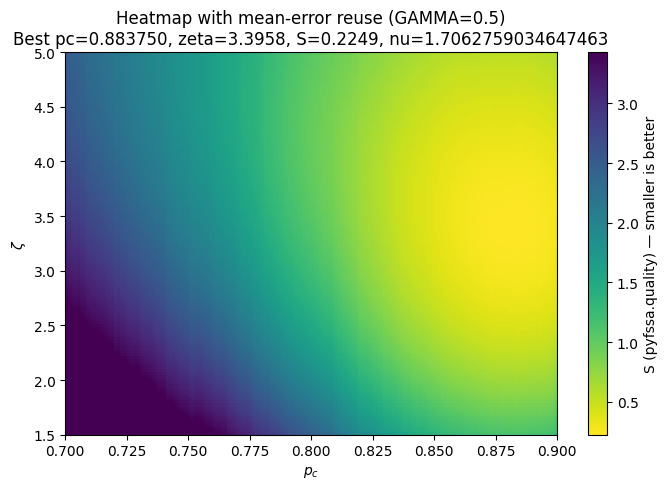

In [35]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力と基本設定
# ======================
npz_path = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"
L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
TEE_cols = [1, 2, 3, 4, 5, 6]    # TEE1..TEE6 を使用

# p窓
pc_min, pc_max = 0.72, 0.9

# ---- 固定 ν ----
NU_FIXED =1.7062759034647463

# 探索レンジ
PC_RANGE   = (0.7, 0.9)
ZETA_RANGE = (1.5,  5.0)
N_PC, N_ZETA = 161, 121

# 誤差スケール（平均err流用時の任意係数）
GAMMA = 0.5   # (=1で素の流用。0.5にすると重み×4になるので注意)

# 誤差フロア（ゼロ重み/過小見積りの暴走回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（variance と "平均の誤差を流用"）
# ======================
dat = np.load(npz_path)
pg = dat["pg"].astype(float)

def key(c): return f"TEE{c}"
a_var   = np.array([dat[f"{key(c)}_var"] for c in TEE_cols], float)       # shape=(nL,nP)
# ここがポイント：分散の誤差に「平均の誤差」を流用
da_mean = np.array([dat[f"{key(c)}_err"] for c in TEE_cols], float) * GAMMA
da_var  = da_mean.copy()

# --- p 窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
if not np.any(mask):
    raise ValueError("p窓にデータがありません。pc_min/max を見直してください。")

pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並べる ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# (p_c, ζ) グリッドで S=quality を評価（νは固定）
# ======================
pc_vals   = np.linspace(*PC_RANGE,   N_PC)
zeta_vals = np.linspace(*ZETA_RANGE, N_ZETA)

S_grid = np.full((N_ZETA, N_PC), np.nan, dtype=float)
bestS, best_pc, best_zeta = np.inf, None, None

for iz, zeta in enumerate(zeta_vals):
    for jp, pc in enumerate(pc_vals):
        try:
            xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                                         pc, NU_FIXED, zeta)
            S = fssa.quality(xs, ys, dys)
        except Exception:
            S = np.inf
        S_grid[iz, jp] = S
        if np.isfinite(S) and S < bestS:
            bestS, best_pc, best_zeta = S, pc, zeta

print(f"Best over grid (nu fixed={NU_FIXED}): "
      f"pc≈{best_pc:.6f}, zeta≈{best_zeta:.4f}, S≈{bestS:.4g}")

# ======================
# 可視化（外れ値で真っ黒回避のため上限クリップは任意）
# ======================
plt.figure(figsize=(7,5))
extent = [pc_vals[0], pc_vals[-1], zeta_vals[0], zeta_vals[-1]]
# 95%パーセンタイルでカラーバー上限クリップ（任意）
finite_S = S_grid[np.isfinite(S_grid)]
vmax = np.percentile(finite_S, 95) if finite_S.size else None
im = plt.imshow(S_grid, extent=extent, origin='lower', aspect='auto',
                cmap="viridis_r", vmin=np.nanmin(S_grid), vmax=vmax)
plt.colorbar(im, label="S (pyfssa.quality) — smaller is better")
plt.xlabel(r"$p_c$")
plt.ylabel(r"$\zeta$")
plt.title(f"Heatmap with mean-error reuse (GAMMA={GAMMA})\n"
          f"Best pc={best_pc:.6f}, zeta={best_zeta:.4f}, S={bestS:.4g}, nu={NU_FIXED}")
plt.tight_layout()
plt.savefig("S_heatmap_meanErrReuse_fixed_nu_17062.png", dpi=300)
plt.show()

# 保存
np.savez("Sgrid_meanErrReuse_fixednu_nu_17062.npz",
         pc_vals=pc_vals, zeta_vals=zeta_vals, S_grid=S_grid,
         nu_fixed=NU_FIXED, pc_range=PC_RANGE, zeta_range=ZETA_RANGE,
         pg_window=(pc_min, pc_max),
         L_list=np.array(L_list), TEE_cols=np.array(TEE_cols),
         gamma=GAMMA, err_floor_rel=ERR_FLOOR_REL)


In [8]:
import numpy as np

fname = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    #print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg[:10] =", data["pg"][:10])


keys: ['pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var', 'TEE5_ave', 'TEE5_err', 'TEE5_var', 'TEE6_ave', 'TEE6_err', 'TEE6_var']
pg[:10] = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79]


In [15]:
import numpy as np
from collections import defaultdict
import re, math

# --- 1) slurmログをパースして {pg: list of [TEE1..TEE6]} を作る ---
bucket = defaultdict(list)
pat = re.compile(r"pg=\s*([0-9.]+).*?TEE1=\s*([-0-9.]+).*?TEE2=\s*([-0-9.]+).*?"
                 r"TEE3=\s*([-0-9.]+).*?TEE4=\s*([-0-9.]+).*?TEE5=\s*([-0-9.]+).*?TEE6=\s*([-0-9.]+)")
with open("slurm-2647584.out") as f:
    for line in f:
        m = pat.search(line)
        if m:
            pg = float(m.group(1))
            tees = list(map(float, m.groups()[1:]))  # 6個
            bucket[pg].append(tees)

pg = np.array(sorted(bucket.keys()))
stack = np.array([bucket[p] for p in pg], dtype=float)   # shape=(nP, nSamples, 6)

# --- 2) 分散とそのブートストラップ標準誤差を推定 ---
def bootstrap_var(x, nboot=1000, rng=np.random.default_rng(0)):
    x = np.asarray(x)
    n = len(x)
    if n <= 3:
        return np.var(x, ddof=1), np.nan  # サンプル少な過ぎ
    vs = []
    for _ in range(nboot):
        idx = rng.integers(0, n, n)
        vs.append(np.var(x[idx], ddof=1))
    return np.var(x, ddof=1), np.std(vs, ddof=1)

var6  = np.zeros((len(pg), 6))
dvar6 = np.zeros((len(pg), 6))
for i in range(len(pg)):
    for k in range(6):
        v, dv = bootstrap_var(stack[i,:,k], nboot=1000)
        var6[i,k]  = v
        dvar6[i,k] = dv

# これを npz に保存（pyfssa にそのまま渡せる形）
out = {"pg": pg}
for k in range(6):
    out[f"TEE{k+1}_var"] = var6[:,k]
    out[f"TEE{k+1}_err"] = dvar6[:,k]          # ← 平均の誤差ではなく、分散の標準誤差！
np.savez_compressed("from_log_var_boot.npz", **out)


In [16]:
import numpy as np

fname = "from_log_var_boot.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    #print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE2_var =", data["TEE2_var"][:21])
print("TEE2_err =", data["TEE2_err"][:21])
print("TEE3_var =", data["TEE3_var"][:21])
print("TEE3_err =", data["TEE3_err"][:21])
print("TEE4_var =", data["TEE4_var"][:21])
print("TEE4_err =", data["TEE4_err"][:21])

keys: ['pg', 'TEE1_var', 'TEE1_err', 'TEE2_var', 'TEE2_err', 'TEE3_var', 'TEE3_err', 'TEE4_var', 'TEE4_err', 'TEE5_var', 'TEE5_err', 'TEE6_var', 'TEE6_err']
pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
TEE2_var = [0.00037377 0.00056611 0.0006318  0.00091905 0.00129875 0.00200333
 0.00279115 0.00453735 0.00594738 0.00758096 0.00759114 0.00684237
 0.00472615 0.00307917 0.00274834 0.00192102 0.00153818 0.00115939
 0.00097333 0.00067782 0.00046904]
TEE2_err = [2.52418238e-05 4.27488296e-05 5.14104226e-05 6.63318993e-05
 9.05290671e-05 1.58888470e-04 1.87259147e-04 3.00359581e-04
 3.79392256e-04 4.41402051e-04 4.43306156e-04 4.61853135e-04
 3.01929687e-04 1.68085999e-04 1.56770371e-04 1.18221242e-04
 9.41573867e-05 7.73609349e-05 5.84898764e-05 3.99925612e-05
 2.86375563e-05]
TEE3_var = [0.00051691 0.00064192 0.00068061 0.0007824  0.00101593 0.00130398
 0.0018448  0.00322954 0.00543799 0.0080001  0.01003677 0.01090978
 0.00

In [17]:
import numpy as np

# ===== 入力 =====
AVE_NPZ = "Lx_24_Nd_500_NT_17280_px_0.0_MPI_hexagonal6.npz"   # 例: 'pg', 'TEE{i}_ave', 'TEE{i}_ave_err' を含む
VAR_NPZ = "from_log_var_boot.npz"   # 例: 'pg', 'TEE{i}_var', 'TEE{i}_err'     を含む
OUT_NPZ = "TEE_merged.npz"

# あなたが指定するサイズ（数値）。例：TEE2=√12, TEE3=√18 など
SIZE = {
    "TEE1": np.sqrt(6),
    "TEE2": np.sqrt(12),
    "TEE3": np.sqrt(18),
    "TEE4": np.sqrt(24),   # ←必要な値を入れてください
    "TEE5": np.sqrt(30),
    "TEE6": np.sqrt(36),
}

# ===== マージ処理 =====
za = np.load(AVE_NPZ)
zv = np.load(VAR_NPZ)

pg_a = za["pg"]
pg_v = zv["pg"]
if not np.allclose(pg_a, pg_v):
    raise ValueError("pg が ave と var で一致していません。揃えてから実行してください。")

out = {"pg": pg_a}

for i in range(1, 7):
    key = f"TEE{i}"

    # サイズ（あなた指定の数値を保存）
    if key not in SIZE:
        raise KeyError(f"SIZE に {key} の指定がありません。")
    out[f"{key}_size"] = float(SIZE[key])

    # ave と誤差（誤差が無ければスキップでOK）
    out[f"{key}_ave"] = za[f"{key}_ave"]
    if f"{key}_err" in za:
        out[f"{key}_ave_err"] = za[f"{key}_err"]

    # var と誤差（あなたの形式に合わせて *_err を拾う）
    out[f"{key}_var"] = zv[f"{key}_var"]
    if f"{key}_err" in zv:               # 例：分散のブート誤差を 'TEE{i}_err' で保存している
        out[f"{key}_var_err"] = zv[f"{key}_err"]
    elif f"{key}_err" in zv:         # 別名対応
        out[f"{key}_var_err"] = zv[f"{key}_err"]

# 保存
np.savez_compressed(OUT_NPZ, **out)
print(f"Wrote {OUT_NPZ} with keys:", list(out.keys()))


Wrote TEE_merged.npz with keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']


In [18]:
import numpy as np

fname = "TEE_merged.npz"

# npzファイルを開く
data = np.load(fname)

# キー一覧を表示
print("keys:", data.files)

# 各キーの shape や dtype を確認
for k in data.files:
    arr = data[k]
    #print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# 例えば pg をちょっと見る
print("pg =", data["pg"][:21])
print("TEE1_var_err =", data["TEE1_var_err"][:21])
#print("TEE2_var_err =", data["TEE2_var_err"][:21])
#print("TEE3_var_err =", data["TEE3_var_err"][:21])
#print("TEE4_var_err =", data["TEE4_var_err"][:21])
#print("TEE5_var_err =", data["TEE5_var_err"][:21])
#print("TEE6_var_err =", data["TEE6_var_err"][:21])

keys: ['pg', 'TEE1_size', 'TEE1_ave', 'TEE1_ave_err', 'TEE1_var', 'TEE1_var_err', 'TEE2_size', 'TEE2_ave', 'TEE2_ave_err', 'TEE2_var', 'TEE2_var_err', 'TEE3_size', 'TEE3_ave', 'TEE3_ave_err', 'TEE3_var', 'TEE3_var_err', 'TEE4_size', 'TEE4_ave', 'TEE4_ave_err', 'TEE4_var', 'TEE4_var_err', 'TEE5_size', 'TEE5_ave', 'TEE5_ave_err', 'TEE5_var', 'TEE5_var_err', 'TEE6_size', 'TEE6_ave', 'TEE6_ave_err', 'TEE6_var', 'TEE6_var_err']
pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
TEE1_var_err = [6.71509987e-05 9.19479566e-05 9.23577106e-05 1.24799735e-04
 1.26078418e-04 1.59220404e-04 2.09123697e-04 2.32818873e-04
 2.11745676e-04 2.36665139e-04 2.25188531e-04 1.74371571e-04
 1.25398931e-04 8.76913914e-05 8.72910121e-05 6.70246113e-05
 6.49983767e-05 5.39933019e-05 4.56617452e-05 4.03883958e-05
 3.55895805e-05]


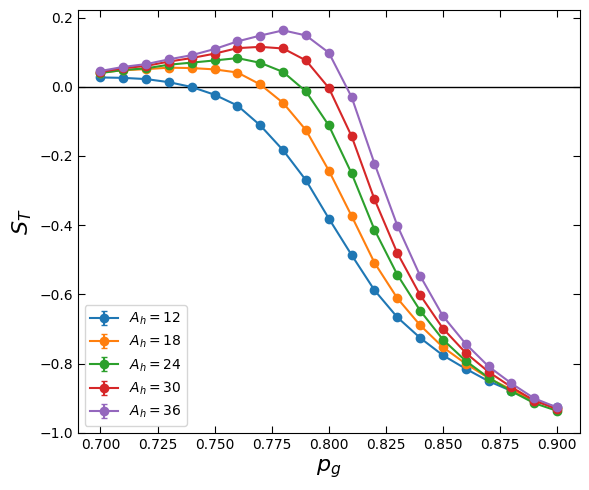

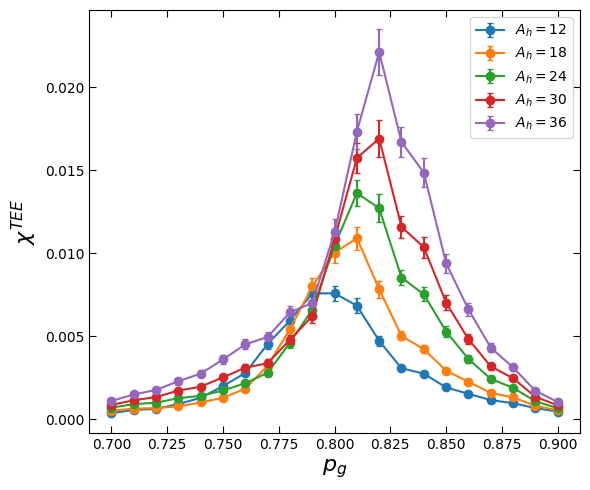

In [19]:
# ave/var を誤差つきで可視化（凡例は *_size）
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = "TEE_merged.npz"   # ここをあなたのファイルに
SERIES   = [2, 3, 4, 5, 6] # 描きたい TEE 番号

z  = np.load(NPZ_PATH)
pg = z["pg"].astype(float)

def get(key):  # 存在チェックつき取得
    if key not in z:
        raise KeyError(f"'{key}' が {NPZ_PATH} にありません")
    return z[key].astype(float)


labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]

# SERIES と labels の対応を作る（順番対応）
if len(labels) < len(SERIES):
    raise ValueError("labels の数が SERIES より少ないです。対応する分だけ用意してください。")
label_map = {s: labels[idx] for idx, s in enumerate(SERIES)}

# --- ave ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    ave    = get(f"TEE{i}_ave")
    aveerr = get(f"TEE{i}_ave_err")
    ax.errorbar(pg, ave, yerr=aveerr, fmt='o-', capsize=2, label=label_map[i])

ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$S_{T}$",fontsize=16)
#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)
ax.axhline(y=0, color='k', lw=1)
ax.set_ylim(-1)
fig.tight_layout()
fig.savefig("TEE_ave_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


# --- var ± err ---
fig, ax = plt.subplots(figsize=(6,5))
for i in SERIES:
    var    = get(f"TEE{i}_var")
    varerr = get(f"TEE{i}_var_err")
    if len(var) != len(pg) or len(varerr) != len(pg):
        raise ValueError(f"TEE{i} の長さが pg と一致しません")
    ax.errorbar(pg, var, yerr=varerr, fmt='o-', capsize=2, label=label_map[i])
ax.set_xlabel("$p_g$",fontsize=16)
ax.set_ylabel("$\chi^{TEE}$",fontsize=16)

#ax.set_title("Average with error")
ax.legend(title="")

# 目盛りはメジャーのみを内側へ（補助目盛りは使わない）
ax.tick_params(direction='in', which='major', top=True, right=True, length=5)
ax.minorticks_off()  # 補助目盛を完全に無効化
ax.tick_params(which='minor', bottom=False, left=False, top=False, right=False)

fig.tight_layout()
fig.savefig("TEE_var_px_0.png", dpi=300, bbox_inches="tight")
plt.show()


=== zeta from peak-height scaling (quadratic+bootstrap) ===
mode(L_eff)=sqrtAh, SERIES=['TEE2', 'TEE3', 'TEE4', 'TEE5', 'TEE6']
TEE2: L_eff= 3.464 | peak=0.00794565 ± 0.00036 | g*≈0.79610 ± 0.00361
TEE3: L_eff= 4.243 | peak=0.011129 ± 0.00059 | g*≈0.80678 ± 0.00177
TEE4: L_eff= 4.899 | peak=0.0139652 ± 0.00071 | g*≈0.81329 ± 0.00196
TEE5: L_eff= 5.477 | peak=0.0174381 ± 0.00095 | g*≈0.81642 ± 0.00166
TEE6: L_eff= 6.000 | peak=0.0221701 ± 0.0014 | g*≈0.81962 ± 0.00087

ζ (MC)   = 1.820004 ± 0.121852
ζ (wOLS) = 1.762189   （参考：重み付きOLSの傾き）


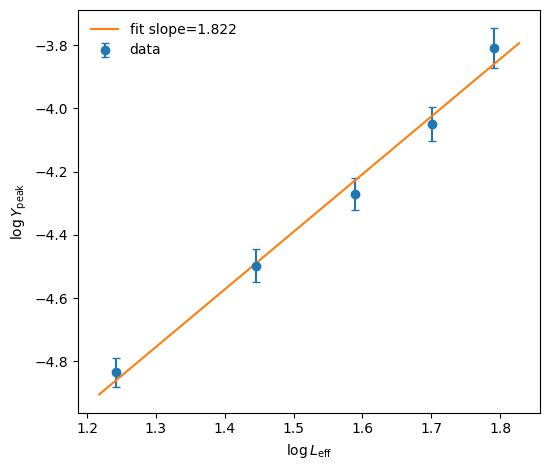

In [20]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# ========= 設定 =========
NPZ_PATH = "from_log_var_boot.npz"
SERIES_KEYS = ["TEE2","TEE3","TEE4","TEE5","TEE6"]  # 有効サイズに対応
EFF_SIZE_MODE = "sqrtAh"   # "sqrtAh" or "Ah"
AH_MAP = {"TEE2":12, "TEE3":18, "TEE4":24, "TEE5":30, "TEE6":36}

# --- ピーク抽出 ---
N_BOOT_PEAK = 2000     # 分散曲線→ピーク高さ/位置のブートストラップ
# --- ζ の誤差 ---
N_BOOT_ZETA = 5000     # ピーク高さ±SEからのMC
RNG = np.random.default_rng(0)

# ========= 関数 =========
def eff_size_from_keys(keys, mode="sqrtAh"):
    Ah = np.array([AH_MAP[k] for k in keys], dtype=float)
    return Ah if mode == "Ah" else np.sqrt(Ah)

def quad_vertex(x0, y0, x1, y1, x2, y2):
    """3点 (x0,y0),(x1,y1),(x2,y2) の二次式頂点 (xv, yv)。a≃0 なら中心点にフォールバック。"""
    denom = (x0-x1)*(x0-x2)*(x1-x2)
    if np.isclose(denom, 0.0):
        return x1, y1
    a = (x2*(y1-y0) + x1*(y0-y2) + x0*(y2-y1)) / denom
    b = (x2*x2*(y0-y1) + x1*x1*(y2-y0) + x0*x0*(y1-y2)) / denom
    if np.isclose(a, 0.0):
        return x1, y1
    xv = -b/(2*a)
    # 範囲外に飛んだら中央点
    if not (min(x0,x2) <= xv <= max(x0,x2)):
        xv = x1
    yv = a*xv*xv + b*xv + (y0 - a*x0*x0 - b*x0)  # c を消去して評価
    return xv, yv

def peak_bootstrap_quadratic(g, y, yerr, nboot=1000, rng=None):
    """
    分散曲線 y(g) に誤差を加えてブートストラップ。
    各試行で argmax 近傍の3点に二次フィットし、サブグリッドのピーク高さ/位置を返す。
    端点に最大が来たらグリッド点を採用。
    """
    if rng is None:
        rng = np.random.default_rng()
    yerr = np.maximum(yerr, 1e-16)
    peaks, xpos = [], []
    n = len(g)
    for _ in range(nboot):
        yb = y + rng.normal(0.0, yerr)
        i = int(np.argmax(yb))
        if 0 < i < n-1:
            xv, yv = quad_vertex(g[i-1], yb[i-1], g[i], yb[i], g[i+1], yb[i+1])
            peaks.append(max(yv, 1e-16))
            xpos.append(xv)
        else:
            peaks.append(max(yb[i], 1e-16))
            xpos.append(g[i])
    peaks = np.asarray(peaks)
    xpos  = np.asarray(xpos)
    return peaks.mean(), peaks.std(ddof=1), xpos.mean(), xpos.std(ddof=1)

def zeta_from_loglog_mc(L_eff, Y_mean, Y_se, nboot=5000, rng=None):
    """Y ~ N(Y_mean, Y_se) を再サンプルし、log–log 直線の傾き ζ をブートストラップ。"""
    if rng is None:
        rng = np.random.default_rng()
    x = np.log(L_eff)
    zetas = []
    for _ in range(nboot):
        ys = np.maximum(rng.normal(Y_mean, Y_se), 1e-16)
        y  = np.log(ys)
        # 最小二乗直線（次数1）。重みは Y_se に反映済みとみなす。
        coeff = np.polyfit(x, y, deg=1)
        zetas.append(coeff[0])
    zetas = np.asarray(zetas)
    return zetas.mean(), zetas.std(ddof=1)

def zeta_weighted_ols(L_eff, Y_mean, Y_se):
    """参考：log–log の重み付きOLS（d(logY) ≈ dY/Y を重みとして使用）。"""
    x = np.log(L_eff)
    y = np.log(np.maximum(Y_mean, 1e-16))
    dy = np.maximum(Y_se, 1e-16)/np.maximum(Y_mean, 1e-16)
    w = 1.0/np.square(dy)
    coeff = np.polyfit(x, y, deg=1, w=w)
    return coeff[0]  # slope

# ========= データ読み込み =========
dat = np.load(NPZ_PATH)
g = dat["pg"].astype(float)

# ========= 系列ごとのピーク抽出 =========
peak_means, peak_ses, peak_pos_mean, peak_pos_se = [], [], [], []
for key in SERIES_KEYS:
    if f"{key}_var" not in dat or f"{key}_err" not in dat:
        raise KeyError(f"npz に {key}_var / {key}_err が見つかりません")
    y  = dat[f"{key}_var"].astype(float)
    dy = dat[f"{key}_err"].astype(float)
    # （必要なら臨界窓でマスク）
    g_use, y_use, dy_use = g, y, dy
    mu, se, gx, gs = peak_bootstrap_quadratic(g_use, y_use, dy_use, nboot=N_BOOT_PEAK, rng=RNG)
    peak_means.append(mu); peak_ses.append(se)
    peak_pos_mean.append(gx); peak_pos_se.append(gs)

peak_means    = np.asarray(peak_means)
peak_ses      = np.asarray(peak_ses)
peak_pos_mean = np.asarray(peak_pos_mean)
peak_pos_se   = np.asarray(peak_pos_se)

# ========= 有効サイズ & ζ =========
if len(SERIES_KEYS) < 3:
    raise ValueError("ζ を推定するには少なくとも3サイズ（3系列）が必要です。")

L_eff = eff_size_from_keys(SERIES_KEYS, mode=EFF_SIZE_MODE)

zeta_mean, zeta_std = zeta_from_loglog_mc(L_eff, peak_means, peak_ses,
                                          nboot=N_BOOT_ZETA, rng=RNG)
zeta_wols = zeta_weighted_ols(L_eff, peak_means, peak_ses)  # 参考

# ========= 出力 =========
print("=== zeta from peak-height scaling (quadratic+bootstrap) ===")
print(f"mode(L_eff)={EFF_SIZE_MODE}, SERIES={SERIES_KEYS}")
for k, Le, mu, se, gx, gs in zip(SERIES_KEYS, L_eff, peak_means, peak_ses, peak_pos_mean, peak_pos_se):
    print(f"{k:>4s}: L_eff={Le:>6.3f} | peak={mu:.6g} ± {se:.2g} | g*≈{gx:.5f} ± {gs:.5f}")
print(f"\nζ (MC)   = {zeta_mean:.6f} ± {zeta_std:.6f}")
print(f"ζ (wOLS) = {zeta_wols:.6f}   （参考：重み付きOLSの傾き）")

# ========= 図（log–log） =========
fig, ax = plt.subplots(figsize=(5.6,4.8))
xlog = np.log(L_eff); ylog = np.log(peak_means)
ylog_err = peak_ses/np.maximum(peak_means,1e-16)  # d(logY) ≈ dY/Y
ax.errorbar(xlog, ylog, yerr=ylog_err, fmt='o', capsize=3, label="data")
# 平均値でのフィット線
coef = np.polyfit(xlog, ylog, deg=1)
xx = np.linspace(xlog.min()*0.98, xlog.max()*1.02, 100)
yy = np.polyval(coef, xx)
ax.plot(xx, yy, '-', label=f"fit slope={coef[0]:.3f}")
ax.set_xlabel(r"$\log L_{\rm eff}$")
ax.set_ylabel(r"$\log Y_{\rm peak}$")
ax.legend(frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig("zeta_peakheight_loglog.png", dpi=300, bbox_inches="tight")
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


[coarse] pc0=0.861011, nu0=1.1200, S=3.4351

=== Variance FSS (fss_merged.npz) ===
['6.00', '7.35', '8.49', '9.49', '10.39']
pc   = 0.931301885 ± 0.028694508
nu   = 2.772531911 ± 0.657521183
zeta = 4.196446475 ± 1.761255094
S     = 2.657134


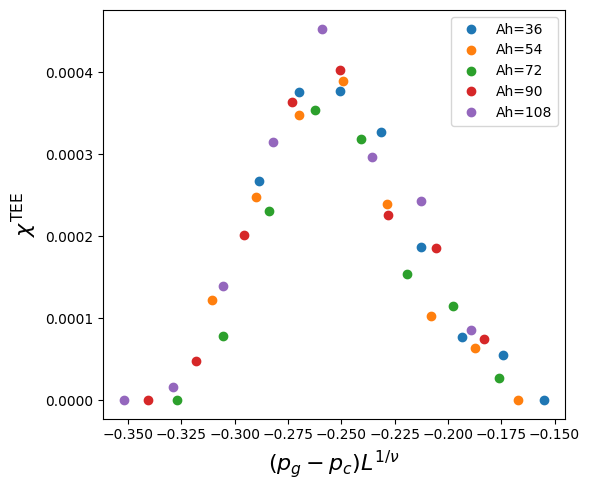

In [21]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import fssa
from scipy.optimize import curve_fit

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"

# --- L は √Ah（あなたの指定） ---
AH = {2:36, 3:54, 4:72, 5:90, 6:108}

# まずは補正の効きやすい小サイズを外して安定化
TEE_cols = [2,3,4,5,6]        # ← 成功したら [2,3,4,5,6] に戻す
L_list   = [np.sqrt(AH[c]) for c in TEE_cols]

# ζを固定（ピーク高さの独立推定 ≈ 1.83 を採用）
FIX_ZETA = False
ZETA_VAL = 1.83

# 誤差フロア（過大にしない）
ERR_FLOOR_REL = 1e-4

# コラプスの |x| 窓（描画時）
S_WINDOW = 2.0

# ======================
# データ読み込み（Var とそのSE）
# ======================
dat = np.load(npz_path, allow_pickle=True)
pg = np.asarray(dat["pg"], float)

def k(c, suf): return f"TEE{c}_{suf}"
A  = np.array([dat[k(c,"var")]     for c in TEE_cols], float)  # shape=(nL,nP)
dA = np.array([dat[k(c,"var_err")] for c in TEE_cols], float)

# ======================
# 放物線で各サイズの g*_L を推定 → 左右対称の p 窓を決定
# ======================
def quad(x,a,b,c): return a*x**2 + b*x + c
def gstar_parabola(pg,y,dy):
    eps = max(1e-12, np.nanmedian(np.abs(y))*1e-6)
    dy  = np.where((dy>0)&np.isfinite(dy), dy, eps)
    i   = int(np.nanargmax(y))
    lo,hi = max(0,i-2), min(len(pg), i+3)
    x,yy,dyy = pg[lo:hi], y[lo:hi], dy[lo:hi]
    if len(x) < 3: return pg[i]
    (Aq,Bq,Cq),_ = curve_fit(quad, x, yy, sigma=dyy, absolute_sigma=True, maxfev=20000)
    gx = -Bq/(2*Aq)
    return gx if (pg.min() <= gx <= pg.max()) else pg[i]

gstars = np.array([gstar_parabola(pg, A[i], dA[i]) for i in range(len(TEE_cols))])
pc_center = float(gstars.mean())
dpg = max(0.04, float(gstars.std()) + 0.02)     # ← 肩が両側入る幅
mask = (pg >= pc_center - dpg) & (pg <= pc_center + dpg)

# 窓で切って昇順に並び替え
pg_use = pg[mask]; order = np.argsort(pg_use)
pg_use = pg_use[order]
A_use  = A[:,  mask][:, order]
dA_use = dA[:, mask][:, order]

# （任意）基線オフセット除去：窓内で最小値を引くと S が改善する系がある
A_base = A_use.min(axis=1, keepdims=True)
A_use  = A_use - A_base

# 誤差フロア（控えめに）
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(A_use))
dA_use = np.maximum(dA_use, eps)

# ======================
# 粗探索 → autoscale（ζ固定）
# ======================
ZETA = ZETA_VAL if FIX_ZETA else 2.0
rhos = np.linspace(pc_center-0.03, pc_center+0.05, 33)
nus  = np.linspace(1.0, 2.2, 31)

bestS, rho0, nu0 = np.inf, None, None
for rh in rhos:
    for nv in nus:
        xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use, rh, nv, ZETA)
        S = fssa.quality(xs, ys, dys)
        if np.isfinite(S) and S < bestS:
            bestS, rho0, nu0 = S, rh, nv
print(f"[coarse] pc0={rho0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")

ret = fssa.autoscale(L_list, pg_use, A_use, dA_use,
                     rho_c0=rho0, nu0=nu0, zeta0=ZETA)
if FIX_ZETA:
    ret.zeta  = ZETA
    ret.dzeta = 0.0

# スケール変換（コラプス座標）と評価関数
xs, ys, dys = fssa.scaledata(L_list, pg_use, A_use, dA_use,
                             ret.rho, ret.nu, ret.zeta)
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS (fss_merged.npz) ===")
print([f"{L:.2f}" for L in L_list])
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")

# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
for i, L in enumerate(L_list):
    ax.plot(xs.T[:, i], ys.T[:, i], 'o', label=f"Ah={int(AH[TEE_cols[i]])}")
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{\rm TEE}$",fontsize=16)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches='tight')
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)



=== Variance FSS===
[6.0, 7.3484692283495345, 8.48528137423857, 9.486832980505138, 10.392304845413264]
pc   = 0.886112922 ± 0.045200030
nu   = 1.765587163 ± 0.370308159
zeta = 3.782281773 ± 0.966369455
S     = 5.031300


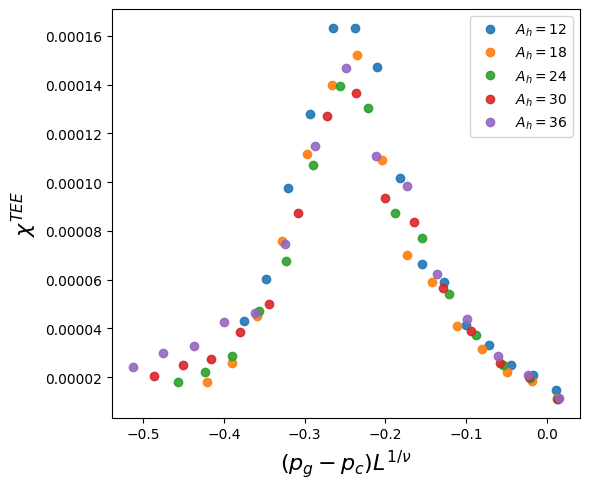

In [22]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import numpy as np
import fssa
import matplotlib.pyplot as plt

# ======================
# 入力
# ======================
npz_path = "TEE_merged.npz"   # ブートストラップで作ったnpz
# Lは √(セル数) を例として使用（あなたの流儀に合わせて変更）
#L_list   = [np.sqrt(18), np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
L_list   = [np.sqrt(36), np.sqrt(54), np.sqrt(72), np.sqrt(90), np.sqrt(108)]
# TEEのどれを使うか（L_listと同数・同順に合わせる）
#TEE_cols = [1,2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例
TEE_cols = [2, 3, 4, 5, 6]  # = TEE2..TEE6 を使う例

# クリティカル窓（まず少し広め→収束後に狭めるのが吉）
pc_min = 0.75
pc_max = 0.89

# ζを固定すると相関が切れて安定（推奨）
FIX_ZETA = False
ZETA_VAL = 2.9
# ζを自由にしたい場合は False にして下の zeta0 を初期値とする
zeta0    = 3.7


rho_c0, nu0 = 0.85, 1.8


# 誤差フロア（ゼロ重み回避）
ERR_FLOOR_REL = 1e-3

# ======================
# データ読み込み（分散とそのSE）
# ======================
dat = np.load(npz_path)
pg = dat["pg"]

# 例：TEE2..TEE6 を使う
def col_to_key(c): return f"TEE{c}"
a_var  = np.array([dat[f"{col_to_key(c)}_var"] for c in TEE_cols], float)  # shape=(nL,nP)
da_var = np.array([dat[f"{col_to_key(c)}_var_err"] for c in TEE_cols], float)

# --- p窓 ---
mask = (pg >= pc_min) & (pg <= pc_max)
pg_use     = pg[mask]
a_var_use  = a_var[:,  mask]
da_var_use = da_var[:, mask]

# --- p を昇順に並び替え（重要） ---
order = np.argsort(pg_use)
pg_use     = pg_use[order]
a_var_use  = a_var_use[:,  order]
da_var_use = da_var_use[:, order]

# --- 誤差フロア ---
eps = ERR_FLOOR_REL * np.nanmedian(np.abs(a_var_use))
da_var_use = np.maximum(da_var_use, eps)

# ======================
# 粗探索で初期値（pc, nu）を作る
# ======================
"""rhos = np.linspace(pg_use.min(), pg_use.max(), 31)
nus  = np.linspace(0.8, 3.0, 30)
bestS, rho_c0, nu0 = np.inf, None, None

for rh in rhos:
    for nv in nus:
        zeta = ZETA_VAL if FIX_ZETA else zeta0
        xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use, rh, nv, zeta)
        S = fssa.quality(xs, ys, dys)
        if S < bestS and np.isfinite(S):
            bestS, rho_c0, nu0 = S, rh, nv"""

#print(f"[coarse] pc0={rho_c0:.6f}, nu0={nu0:.4f}, S={bestS:.4f}")

# ======================
# autoscale 本番
# ======================
if FIX_ZETA:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)
    # ζ固定
    ret.zeta  = ZETA_VAL
    ret.dzeta = 0.0
else:
    ret = fssa.autoscale(L_list, pg_use, a_var_use, da_var_use,
                         rho_c0=rho_c0, nu0=nu0, zeta0=zeta0)

# スケール変換（コラプス座標）
xs, ys, dys = fssa.scaledata(L_list, pg_use, a_var_use, da_var_use,
                             ret.rho, ret.nu, ret.zeta)

# 評価関数
from fssa import quality
S_val = quality(xs, ys, dys)

# ======================
# 結果表示
# ======================
print("\n=== Variance FSS===")
print(L_list)
print(f"pc   = {ret.rho:.9f} ± {getattr(ret, 'drho', np.nan):.9f}")
print(f"nu   = {ret.nu:.9f} ± {getattr(ret, 'dnu',  np.nan):.9f}")
print(f"zeta = {ret.zeta:.9f} ± {getattr(ret, 'dzeta', np.nan):.9f}" + (" (FIXED)" if FIX_ZETA else ""))
print(f"S     = {S_val:.6f}")


# ======================
# プロット（コラプス後）
# ======================
fig, ax = plt.subplots(figsize=(6,5))
labels = [r"$A_h=12$", r"$A_h=18$", r"$A_h=24$", r"$A_h=30$", r"$A_h=36$"]
for i, (L, label) in enumerate(zip(L_list, labels)):
    """ax.errorbar(xs.T[:, i], ys.T[:, i], yerr=dys.T[:, i],
                fmt='o', ms=5, capsize=3, label=label, alpha=0.9)"""
    ax.plot(xs.T[:, i], ys.T[:, i],'o', label=label, alpha=0.9)
ax.set_xlabel(r"$(p_g-p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$\chi^{TEE}$",fontsize=16)
ax.legend( fontsize=10)
ax.grid(False)
fig.tight_layout()
fig.savefig("TEE_collapse_px_0.png", dpi=300, bbox_inches="tight")
plt.show()
